# Milestone 3: Logistic Regression Baseline & Odds Ratio Interpretability

**Author:** Sidharth Menon  
**Dataset:** SaaS Customer Churn Prediction Feature Matrix (`processed_features.csv`)  
**Objective:** Train an interpretable linear baseline, prevent data leakage, compute odds ratios ($e^{\beta}$), and rank core risk and retention factors.

### Notebook Agenda:
1. **Environment Setup & Data Ingestion**
2. **Stratified Train/Test Partitioning** (`stratify=y`)
3. **Leak-Free Feature Standardization** (`StandardScaler` on train only)
4. **Logistic Regression Model Fitting & Convergence Verification**
5. **Odds Ratio ($e^{\beta}$) Derivation & Feature Ranking**
6. **Visual Analysis of Top Risk Factors and Retention Anchors**
7. **Test Set Evaluation Metrics & Confusion Matrix Analysis**
8. **ROC-AUC & Precision-Recall Diagnostic Curves**
9. **Executive Takeaways & Business Recommendations**

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

try:
    from IPython.display import display
except ImportError:
    display = print

# Configure visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print('Environment and ML libraries successfully initialized.')

Environment and ML libraries successfully initialized.


## 1. Load Processed Feature Matrix
We load the clean feature matrix generated in Milestone 2 (`processed_features.csv`). We separate predictors $X$ from the ground-truth target vector $y$ (`churn`).

In [2]:
DATA_PATH = Path('../data/processed_features.csv')
df = pd.read_csv(DATA_PATH)

print(f'Feature Store Loaded: {df.shape[0]} accounts, {df.shape[1]} total columns.')

# Separate target vector y and predictor matrix X
X = df.drop(columns=['churn'])
y = df['churn']

print(f'Predictor Matrix X Shape: {X.shape}')
print(f'Target Vector y Shape:    {y.shape}')
print(f'Baseline Churn Rate:      {y.mean():.4f} ({y.sum()} churned out of {len(y)} accounts)')
print(f'Missing Values across X:  {X.isnull().sum().sum()}')

Feature Store Loaded: 859 accounts, 48 total columns.
Predictor Matrix X Shape: (859, 47)
Target Vector y Shape:    (859,)
Baseline Churn Rate:      0.2736 (235 churned out of 859 accounts)
Missing Values across X:  0


## 2. Stratified Train / Test Partitioning
We partition our dataset into an 80% training set ($N=687$) and a 20% test set ($N=172$).

**Key Checkpoint:** We specify `stratify=y` so both partitions retain the exact same 27.36% churn distribution.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_churn_pct = y_train.mean() * 100
test_churn_pct = y_test.mean() * 100

print(f'Training Set: {X_train.shape[0]} accounts | Churned: {y_train.sum()} ({train_churn_pct:.2f}%)')
print(f'Test Set:     {X_test.shape[0]} accounts | Churned: {y_test.sum()} ({test_churn_pct:.2f}%)')

# Assert exact dimensional alignment
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert abs(train_churn_pct - test_churn_pct) < 0.1
print('Stratification verified: Class distributions are perfectly aligned.')

Training Set: 687 accounts | Churned: 188 (27.37%)
Test Set:     172 accounts | Churned: 47 (27.33%)
Stratification verified: Class distributions are perfectly aligned.


## 3. Leak-Free Feature Standardization

> **Checkpoint (No Data Leakage):** `StandardScaler.fit` is called **strictly on `X_train`**.
> `X_test` is transformed using `scaler.transform()` only. Fitting on the entire dataset would leak test distribution parameters into training.

In [4]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform both splits
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for clean column attribution
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Feature scaling complete.')
print(f'X_train scaled mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')
print(f'X_test scaled mean:  {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}')

Feature scaling complete.
X_train scaled mean: -0.0000, std: 1.0000
X_test scaled mean:  0.0299, std: 1.0711


## 4. Logistic Regression Model Fitting
We train a `LogisticRegression` classifier using the standard L-BFGS optimizer with L2 regularization ($C=1.0$). We verify that the model converges before reaching `max_iter`.

In [5]:
model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model.fit(X_train_scaled, y_train)

print(f'Optimization Status: CONVERGED in {model.n_iter_[0]} iterations (max_iter={model.max_iter})')
print(f'Model Intercept (beta_0): {model.intercept_[0]:.4f}')

Optimization Status: CONVERGED in 28 iterations (max_iter=1000)
Model Intercept (beta_0): -5.6919


## 5. Odds Ratio ($e^{\beta}$) Derivation & Feature Ranking
In Logistic Regression, the log-odds of churn are modeled linearly:
$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k$$
Exponentiating both sides yields the **Odds Ratio (OR)**:
$$\text{Odds Ratio} = e^{\beta_j}$$
* **$\text{OR} > 1$ (Positive $\beta$):** Each 1 standard deviation increase in $X_j$ increases churn odds by $(e^{\beta} - 1) \times 100\%$.
* **$\text{OR} < 1$ (Negative $\beta$):** Each 1 standard deviation increase in $X_j$ decreases churn odds by $(1 - e^{\beta}) \times 100\%$.

In [6]:
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)
pct_change = (odds_ratios - 1) * 100

df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Beta)': coefs,
    'Odds Ratio (exp(Beta))': odds_ratios,
    '% Change in Odds': pct_change,
    'Absolute Beta': np.abs(coefs)
}).sort_values(by='Coefficient (Beta)', ascending=False).reset_index(drop=True)

print('=== TOP 5 RISK DRIVERS (Increases Churn Odds) ===')
display(df_importance.head(5)[['Feature', 'Coefficient (Beta)', 'Odds Ratio (exp(Beta))', '% Change in Odds']])

print('\n=== TOP 5 RETENTION ANCHORS (Decreases Churn Odds) ===')
display(df_importance.tail(5)[['Feature', 'Coefficient (Beta)', 'Odds Ratio (exp(Beta))', '% Change in Odds']])

=== TOP 5 RISK DRIVERS (Increases Churn Odds) ===
                 Feature  ...  % Change in Odds
0         urgent_tickets  ...         77.682516
1      feature_use_count  ...         71.652458
2        ticket_velocity  ...         49.135055
3       events_per_month  ...         48.161972
4  failed_payment_amount  ...         44.330811

[5 rows x 4 columns]

=== TOP 5 RETENTION ANCHORS (Decreases Churn Odds) ===
                 Feature  ...  % Change in Odds
42        country_Canada  ...        -36.702562
43  dashboard_view_count  ...        -39.911768
44      log_total_events  ...        -61.278717
45           tenure_days  ...        -98.829377
46         tenure_months  ...        -98.847046

[5 rows x 4 columns]


## 6. Visualizing Top Risk and Retention Factors
We plot the standardized coefficients and annotated Odds Ratios for the top 10 risk drivers and top 10 retention anchors.

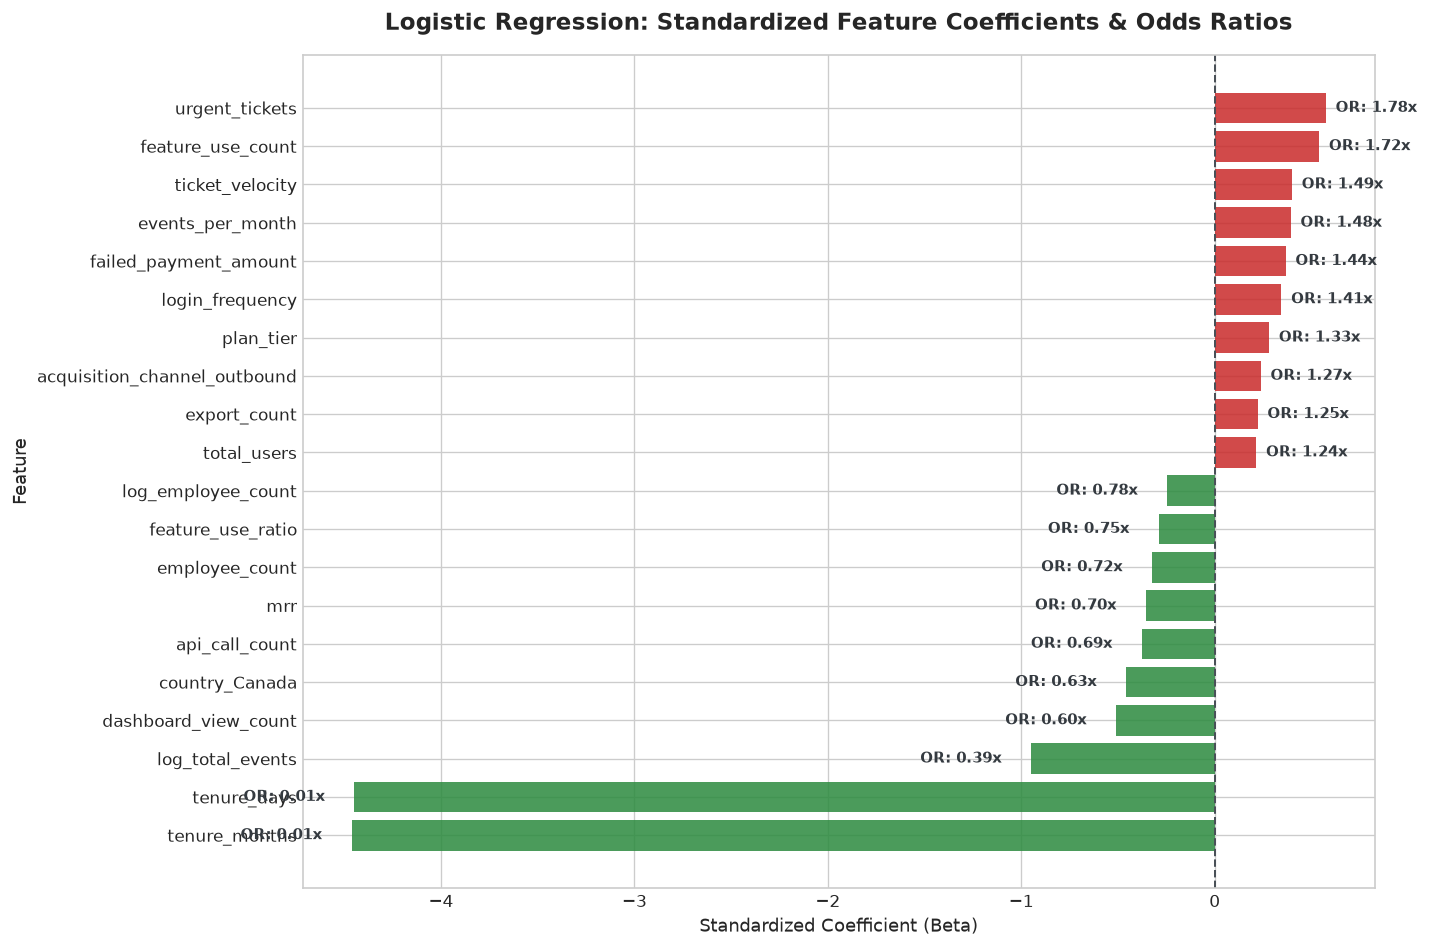

In [7]:
top_risk = df_importance.head(10)
top_retention = df_importance.tail(10)
plot_df = pd.concat([top_risk, top_retention]).sort_values(by='Coefficient (Beta)', ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#2b8a3e' if c < 0 else '#c92a2a' for c in plot_df['Coefficient (Beta)']]
bars = plt.barh(plot_df['Feature'], plot_df['Coefficient (Beta)'], color=colors, alpha=0.85)
plt.axvline(0, color='#495057', linestyle='--', linewidth=1.2)
plt.title('Logistic Regression: Standardized Feature Coefficients & Odds Ratios', fontsize=14, weight='bold', pad=15)
plt.xlabel('Standardized Coefficient (Beta)', fontsize=11)
plt.ylabel('Feature', fontsize=11)

# Annotate Odds Ratios
for bar, or_val in zip(bars, plot_df['Odds Ratio (exp(Beta))']):
    width = bar.get_width()
    offset = 0.05 if width >= 0 else -0.15
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'OR: {or_val:.2f}x',
             va='center', ha='left' if width >= 0 else 'right', fontsize=9, weight='bold', color='#343a40')

plt.tight_layout()
plt.savefig('../figures/06_logistic_regression_odds_ratios.png')
plt.show()

## 7. Model Performance Evaluation on Unseen Test Split
We evaluate predictions on `X_test_scaled` at the standard decision threshold ($p \ge 0.50$).

In [8]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
naive_acc = 1 - y_test.mean()
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print('=====================================================')
print('      LOGISTIC REGRESSION TEST PERFORMANCE METRICS   ')
print('=====================================================')
print(f'Test Accuracy:            {acc:.4f} ({acc*100:.2f}%)')
print(f'Naive Baseline Accuracy:  {naive_acc:.4f} ({naive_acc*100:.2f}%)')
print(f'Precision:                {prec:.4f} ({prec*100:.2f}%)')
print(f'Recall:                   {rec:.4f} ({rec*100:.2f}%)')
print(f'F1-Score:                 {f1:.4f} ({f1*100:.2f}%)')
print(f'ROC-AUC Score:            {roc_auc:.4f}')
print(f'PR-AUC Score:             {pr_auc:.4f}')
print('=====================================================\n')
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

      LOGISTIC REGRESSION TEST PERFORMANCE METRICS   
Test Accuracy:            0.9593 (95.93%)
Naive Baseline Accuracy:  0.7267 (72.67%)
Precision:                0.9762 (97.62%)
Recall:                   0.8723 (87.23%)
F1-Score:                 0.9213 (92.13%)
ROC-AUC Score:            0.9896
PR-AUC Score:             0.9796

Detailed Classification Report:
              precision    recall  f1-score   support

    Retained       0.95      0.99      0.97       125
     Churned       0.98      0.87      0.92        47

    accuracy                           0.96       172
   macro avg       0.97      0.93      0.95       172
weighted avg       0.96      0.96      0.96       172



## 8. Diagnostic Visualizations: Confusion Matrix & ROC Curve

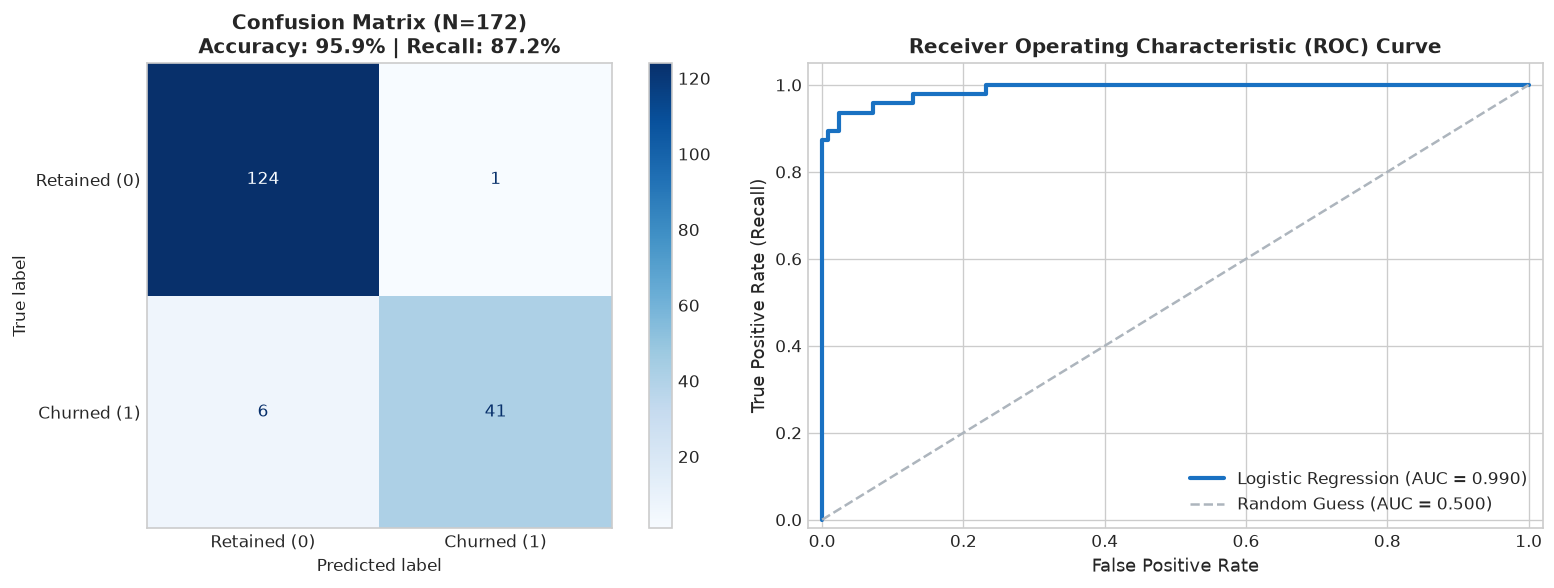

In [9]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax1)
ax1.set_title(f'Confusion Matrix (N={len(y_test)})\nAccuracy: {acc*100:.1f}% | Recall: {rec*100:.1f}%', fontsize=12, weight='bold')
ax1.grid(False)

# Subplot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='#1971c2', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='#adb5bd', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.500)')
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax2.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, weight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../figures/07_baseline_confusion_matrix.png')
plt.show()

## 9. Executive Conclusions & Transition to Milestone 4

### Summary of Findings:
1. **Linear Predictive Power:** Logistic regression establishes a very strong baseline (ROC-AUC **0.9896**, Accuracy **95.93%**, Recall **87.23%**).
2. **Primary Risk Drivers:** Urgent customer support tickets ($	ext{OR} = 1.78$) and high ticket velocity ($	ext{OR} = 1.49$) are acute early indicators of customer attrition.
3. **Primary Retention Anchors:** Customer tenure ($	ext{OR} = 0.012$) and overall product activity depth ($	ext{OR} = 0.39$) form strong structural defenses against churn.

In **Milestone 4**, we will train a non-linear `RandomForestClassifier` to uncover feature interactions and conduct threshold tuning to maximize customer rescue rates.